
This notebook takes BT-Settl models downloaded from http://svo2.cab.inta-csic.es/theory/newov2/index.php?models=bt-settl and does a few things with them:

(1) Convert from air wavelengths to vacuum wavelengths

(2) Resamples the models onto a standard wavelength grid, using a flux conserving algorithm (Spectres)

(3) Uses bilinear interpolation to place them on the same (logt, logg) grid used by the other stellar libraries in FSPS.

(4) Converts the units from per-unit wavelength to per-unit frequency [erg/s/cm2/angstrom -> erg/s/cm2/Hz/sr]
    
(5) Converts them into the same binary format that FSPS uses for all of its other stellar libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import tqdm
import re
import os
import glob
import spectres
from astropy import table, units as u
import pyvo

%matplotlib inline

In [2]:
# Solar abundances (mass fractions): Asplund et al. 2009, Scott et al. 2015

sol_abund = dict(
    H=7.375E-01,
    He=2.493E-01,
    C=2.365E-03,
    N=6.929E-04,
    O=5.733E-03,
    Ne=1.257E-03,
    Na=2.728E-05,
    Mg=6.918E-04
)
sol_abund_z = np.sum(list(sol_abund.values())) - sol_abund['H'] - sol_abund['He']

print(sol_abund_z)

0.010766979999999954


In [3]:
# SPS_HOME = os.getenv('SPS_HOME')
SPS_HOME = os.path.abspath(os.path.join(os.getcwd(), '..'))

# choose one metallicity value for this run
logzi = +0.0

print(SPS_HOME)

/Users/mreefe/Dropbox/Astrophysics/fsps_dev


In [4]:
# Define the teff, logg, and logz arrays that cover the grid of BT-Settl models

teff_1 = np.arange(400, 7000, 100)
teff_2 = np.arange(7000, 12000, 200)
teff_3 = np.arange(12000, 20000, 500)
teff_4 = np.arange(20000, 71000, 1000)
teff = np.concatenate((teff_1, teff_2, teff_3, teff_4))
logt = np.log10(teff)

logg = np.arange(-0.5, 6.5, 0.5)

logz = np.arange(-4.0, 0.5, 0.5)
logz = np.concatenate((logz, [0.3, 0.5]))

print(logt)
print(logg)
print(logz)

[2.60205999 2.69897    2.77815125 2.84509804 2.90308999 2.95424251
 3.         3.04139269 3.07918125 3.11394335 3.14612804 3.17609126
 3.20411998 3.23044892 3.25527251 3.2787536  3.30103    3.32221929
 3.34242268 3.36172784 3.38021124 3.39794001 3.41497335 3.43136376
 3.44715803 3.462398   3.47712125 3.49136169 3.50514998 3.51851394
 3.53147892 3.54406804 3.5563025  3.56820172 3.5797836  3.59106461
 3.60205999 3.61278386 3.62324929 3.63346846 3.64345268 3.65321251
 3.66275783 3.67209786 3.68124124 3.69019608 3.69897    3.70757018
 3.71600334 3.72427587 3.73239376 3.74036269 3.74818803 3.75587486
 3.76342799 3.77085201 3.77815125 3.78532984 3.79239169 3.79934055
 3.80617997 3.81291336 3.81954394 3.8260748  3.83250891 3.83884909
 3.84509804 3.8573325  3.86923172 3.88081359 3.8920946  3.90308999
 3.91381385 3.92427929 3.93449845 3.94448267 3.95424251 3.96378783
 3.97312785 3.98227123 3.99122608 4.         4.00860017 4.01703334
 4.02530587 4.03342376 4.04139269 4.04921802 4.05690485 4.0644

In [5]:
# Define the grid of teff and logg that cover the grid of FSPS's models
logt_fsps = np.loadtxt(os.path.join(SPS_HOME, 'SPECTRA/BaSeL3.1/basel_logt.dat'))
logg_fsps = np.loadtxt(os.path.join(SPS_HOME, 'SPECTRA/BaSeL3.1/basel_logg.dat'))

print(logt_fsps)
print(logg_fsps)

[3.30103 3.34242 3.39794 3.44716 3.47712 3.50515 3.52504 3.54407 3.57403
 3.60206 3.62839 3.65321 3.67669 3.69897 3.72016 3.74036 3.75967 3.77815
 3.79588 3.81291 3.8293  3.8451  3.86034 3.87506 3.8893  3.90309 3.91645
 3.92942 3.94201 3.95424 3.96614 3.97772 3.989   4.      4.02119 4.04139
 4.0607  4.07918 4.09691 4.11394 4.14613 4.17609 4.20412 4.23045 4.25527
 4.27875 4.30103 4.32222 4.34242 4.36173 4.38021 4.39794 4.41497 4.43136
 4.44716 4.4624  4.47712 4.49136 4.50515 4.51851 4.53148 4.54407 4.57403
 4.60206 4.62839 4.65321 4.67669 4.69897]
[-1.02 -0.7  -0.51 -0.29  0.    0.28  0.5   0.6   0.87  1.    1.5   2.
  2.5   3.    3.5   4.    4.5   5.    5.5 ]


In [6]:
# Framework for grabbing Tubingen NLTE Model Atmospheres (TMAP)
svc = pyvo.dal.SSAService('http://dc.g-vo.org/theossa/q/ssa/ssap.xml')

def _wiggle(val, pc=0.02):
    if val is not None:
        return "%s/%s" % ((1-pc)*val, (1+pc)*val)

def grab_tmap_spectrum(teff=None, logg=None, metallicity=1.):
    # teff in K
    # logg in cm/s^2
    # metallicity in solar units
    pars = dict()
    pars['format'] = "votable"
    pars['t_eff'] = _wiggle(teff)
    pars['log_g'] = _wiggle(logg)
    for el, abundance in sol_abund.items():
        pars[f'w_{el}'] = _wiggle(abundance * metallicity)
    
    print(pars)
    return svc.create_query(**pars).execute()

In [65]:
_wiggle(2.3635e-03, 0.02)

'0.0023162300000000003/0.00241077'

In [58]:
t = svc.create_query(
    format='votable',
    t_eff=100000,
    log_g=6.0,
    # w_H=_wiggle(0.7375, pc=0.02),
    # w_He=_wiggle(0.2493, pc=0.02),
    # w_C=_wiggle(2.365E-03, pc=0.02),
    # w_N=_wiggle(6.929E-04, pc=0.02),
    # w_O=_wiggle(5.733E-03, pc=0.02),
    # w_Ne=_wiggle(1.257E-03, pc=0.02),
    # w_Na=_wiggle(2.728E-05, pc=0.02),
    # w_Mg=_wiggle(6.918E-04, pc=0.02)
).execute()

print(len(t))

47


In [60]:
good = np.where((t['ssa_specstart'] < 900e-10) & (t['ssa_specend'] > 1800e-10) & (t['ssa_fluxcalib'] == 'ABSOLUTE'))[0]
waves = []
specs = []

for i, ti in enumerate(t):
    if i in good:
        data = table.Table.read(ti.acref)
        waves.append(data['spectral'])
        specs.append(data['flux'])

In [61]:
ipagb = np.loadtxt('/Users/mreefe/python-fsps/src/fsps/libfsps/SPECTRA/Hot_spectra/ipagb_solar.spec')
teff = np.loadtxt('/Users/mreefe/python-fsps/src/fsps/libfsps/SPECTRA/Hot_spectra/ipagb.teff')
logt = np.log10(teff)

wt = np.nanargmin(np.abs(logt - np.log10(100000.)))
wave = ipagb[:,0]

ipagb[:,wt+1]

array([3.037169e-34, 4.533147e-34, 6.589589e-34, ..., 1.237273e-26,
       1.212653e-26, 1.188760e-26])

/opt/homebrew/Caskroom/miniforge/base/envs/jwst_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


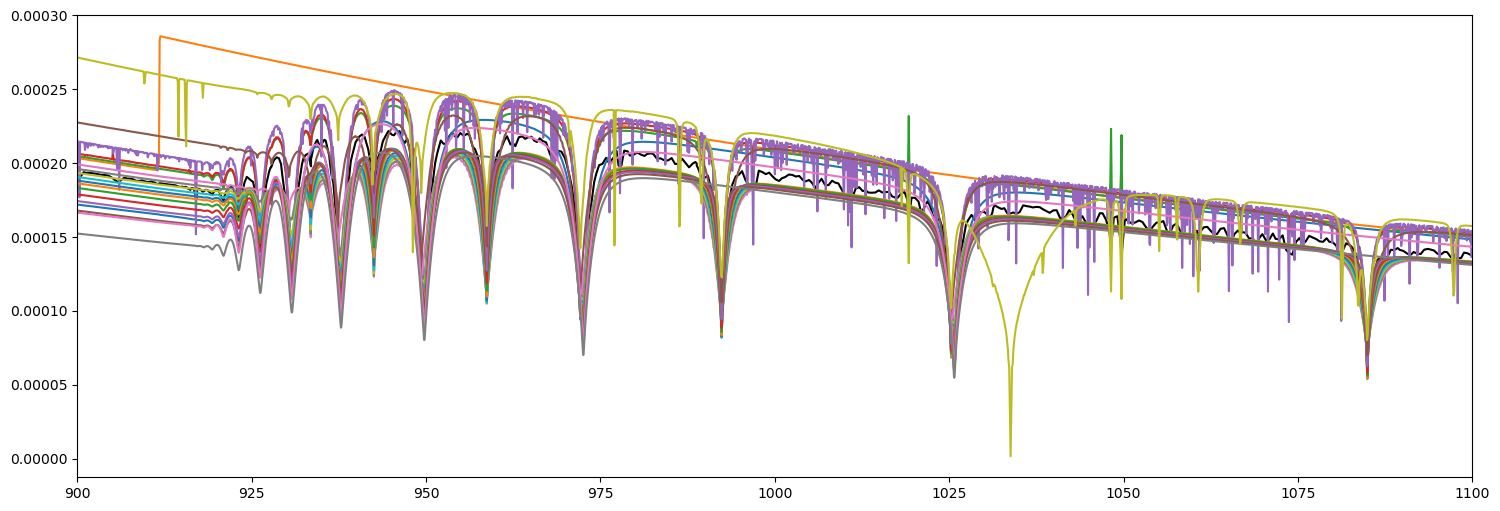

In [62]:
fig, ax = plt.subplots(figsize=(18,6))
wwb = (wave > 900.) & (wave < 1800.)
agb = ipagb[:,wt+1][wwb]*299792458e10/wave[wwb]**2
ax.plot(wave[wwb], agb, 'k-')
for i in range(len(waves)):
    wws = (waves[i] > 900.) & (waves[i] < 1800.)
    ax.plot(waves[i][wws], specs[i][wws]*np.nanmedian(agb)/np.nanmedian(specs[i][wws]))
ax.set_xlim(900, 1100)
# ax.set_ylim(0, np.nanmax(bt)*1.1)
plt.show()

In [101]:
# wavelength must be in angstroms!
def airtovac(wavelength):
    # see: https://www.astro.uu.se/valdwiki/Air-to-vacuum%20conversion
    s = 1e4 / wavelength
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    # do not alter wavelengths below 2000 angstroms 
    wh = np.where(wavelength < 2000.)[0]
    n[wh] = 1.0
    return wavelength * n

In [ ]:

# allocate a buffer for all of the spectra at one metallicity
btsettl_in = np.zeros((len(wavelength), len(logt), len(logg)))

folder = os.path.join(SPS_HOME, 'SPECTRA/BT-Settl/spectra')
files = glob.glob(os.path.join(folder, '*.txt'))

done = np.full(len(files), fill_value='', dtype='<U99')

i = 0
for fpath in tqdm.tqdm(files):

    # check if the file has already been processed - if so, skip it
    if fpath in done:
        continue

    # parse the file name to get the temp, logg, and logz
    fname = os.path.basename(fpath)
    m = re.search(r'^lte([0-9]+)([-+]\d\.\d)([-+]\d\.\d)a?([-+]\d\.\d)?\.BT-.*?\.txt$', fname)
    teff_v = int(m.group(1)) * 100
    logg_v = -float(m.group(2))
    logz_v = float(m.group(3))
    if m.group(4) is not None:
        alpha_v = float(m.group(4))
    else:
        alpha_v = 0.0
    assert logz_v == logzi, f"ERROR: Encountered a file with metallicity {logz_v} != {logzi}. Please clean the 'spectra' directory."

    # find the indices corresponding to these values in the array
    logt_i = np.where(teff == teff_v)[0][0]
    logg_i = np.where(logg == logg_v)[0][0]
    # print(f'Teff = {teff_v:.0f} (index = {logt_i:.0f})')
    # print(f'logg = {logg_v:.1f} (index = {logg_i:.0f})')
    # print(f'logZ = {logz_v:.1f}')

    # check for other models with different alpha enhancements
    fmatches = glob.glob(os.path.join(os.path.dirname(fpath), fname.replace(f'a{m.group(4)}', 'a*')))
    btsettl_o = np.zeros((len(wavelength), len(fmatches)))
    alpha_vs = np.zeros(len(fmatches))

    for j, fmatch in enumerate(fmatches):
        fname2 = os.path.basename(fmatch)
        m = re.search(r'^lte([0-9]+)([-+]\d\.\d)([-+]\d\.\d)a?([-+]\d\.\d)?\.BT-.*?\.txt$', fname2)
        if m.group(4) is not None:
            alpha_vs[j] = float(m.group(4))

        # read in the text file
        wave_i, btsettl_i = np.loadtxt(fmatch, unpack=True)

        # mask out the first wavelength point at 0 angstroms since it breaks to airtovac conversion
        wave_i = wave_i[1:]
        btsettl_i = btsettl_i[1:]

        # convert to vacuum wavelengths when lambda > 2000 angstroms
        wave_vac_i = airtovac(wave_i)

        # perform the flux-conserving resampling onto the output wavelength grid
        btsettl_o[:,j] = spectres.spectres(wavelength, wave_vac_i, btsettl_i, fill=0.)

        # make sure we dont redo this file later
        done[i] = fmatch
        i += 1

    # take the minimum (absolute val) alpha enhancement, since "most" stars are around 0
    minalpha = np.argmin(np.abs(alpha_vs))
    btsettl_o = btsettl_o[:,minalpha]

    # insert it into the 3D array
    btsettl_in[:, logt_i, logg_i] = btsettl_o

    # plot the new and old spectrum to compare them
    # fig, ax = plt.subplots()
    # ax.plot(wave_i, btsettl_i)
    # ax.plot(wavelength, btsettl_o)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # ax.set_xlabel('Wavelength (angstroms)')
    # ax.set_ylabel('Flambda')
    # plt.show()
    # plt.close()


In [ ]:
# allocate an output array buffer
btsettl_out = np.zeros((len(wavelength), len(logt_fsps), len(logg_fsps)))

# Do a bilinear interpolation across the logt and logg axes
for wi in tqdm.trange(len(wavelength)):
    # create the interpolator
    # interp = interpolate.RegularGridInterpolator((logt, logg), btsettl_in[wi,:,:], method='linear',
    #                                              bounds_error=False, fill_value=0.)
    # create the meshgrid to interpolate onto
    LOGT, LOGG = np.meshgrid(logt_fsps, logg_fsps, indexing='ij')
    # btsettl_out[wi,:,:] = interp((LOGT, LOGG))
    # interp = interpolate.LinearNDInterpolator(list(zip(logt_flat, logg_flat)), btsettl_flat[wi,:])
    interp = interpolate.griddata()

In [ ]:
print(10**logt_fsps[3])
print(logg_fsps[3])
print(btsettl_out[:,3,3])
plt.loglog(wavelength, btsettl_out[:,3,3])

print(10**logt[24])
print(logg[1])
plt.loglog(wavelength, btsettl_in[:,24,1])

In [105]:
# Convert the units
c_ang = 299792458e10

for i in range(len(logt_fsps)):
    for j in range(len(logg_fsps)):
        btsettl_out[:,i,j] *= wavelength**2 / c_ang    # <= convert to erg/s/cm2/Hz
        btsettl_out[:,i,j] *= 1/(4*np.pi)              # <= convert to Harvard flux
        # note: insofar as I can tell, FSPS stores its stellar libraries in flux moment or "Harvard flux" units, 
        #       which are off from physical flux units by a factor of 4pi.  See page 244-245 in 
        #       https://ads.harvard.edu/books/1989fsa..book/AbookC09.pdf for more info.
        #       Also see line 199 in getspec.f90 which does the conversion from these units into Lsun/Hz.


In [106]:
# Save as a binary file readable from fortran
# note: np.ndarray.tofile can only save in C-order (row-major) whereas fortran is column-major.
#       to get around this, we can just reverse the order of the axes before saving.
# note: BT-Settl grids use solar metallicity and abundances from Asplund et al. (2009), where Z = 0.0134
zsun = 0.0134
z = 10**logzi * zsun
btsettl_out.astype(np.float32).T.tofile(os.path.join(SPS_HOME, f'SPECTRA/BT-Settl/btsettl_z{z:.4f}.spectra.bin'))

In [107]:
# Store spectral resolution as -0 km/s
# Why? BT-Settl are atmospheric models so they don't really have a spectral resolution. The reason for the negative is to be consistent
# with FSPS's standard of using negative values for "poorly defined" spectral resolutions.
res = np.full((len(wavelength),), fill_value=-0.0)

In [108]:
# save other ancillary files
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/BT-Settl/btsettl.lambda'), wavelength, fmt='%12.4f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/BT-Settl/zlegend.dat'), 10**logz[4:]*zsun, fmt='%6.4f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/BT-Settl/btsettl.res'), res, fmt='%.1f')